<a href="https://colab.research.google.com/github/Aysha2004/S7_INTERNSHIP/blob/main/S7_Internship_d5_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import zipfile
import os
import cv2

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 506


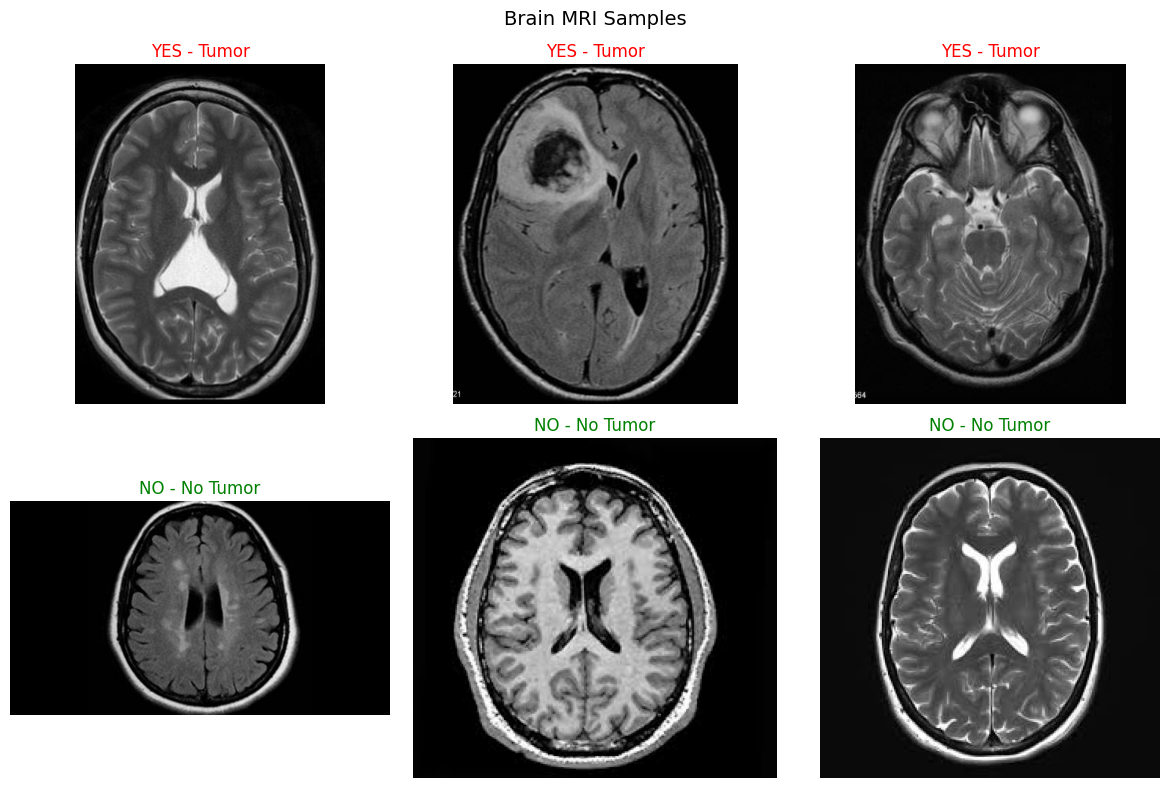

In [61]:
import matplotlib.pyplot as plt
import cv2
import os

yes_folder = "extracted_images/brain_tumor_dataset/yes"
no_folder  = "extracted_images/brain_tumor_dataset/no"

# Get 3 images from each folder
yes_files = os.listdir(yes_folder)[:3]
no_files  = os.listdir(no_folder)[:3]

plt.figure(figsize=(12, 8))

# Show 3 YES images
for i, file in enumerate(yes_files):
    img = cv2.imread(os.path.join(yes_folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"YES - Tumor", color='red')
    plt.axis('off')

# Show 3 NO images
for i, file in enumerate(no_files):
    img = cv2.imread(os.path.join(no_folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 4)
    plt.imshow(img)
    plt.title(f"NO - No Tumor", color='green')
    plt.axis('off')

plt.suptitle("Brain MRI Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
images = []
image_labels = []

# YES = Tumor
for file in os.listdir(yes_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(yes_folder, file)
        img = cv2.imread(img_path)

        if img is not None:
            images.append(img)
            image_labels.append(1)

# NO = No Tumor
for file in os.listdir(no_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(no_folder, file)
        img = cv2.imread(img_path)

        if img is not None:
            images.append(img)
            image_labels.append(0)

print("Images loaded :", len(images))
print("Labels created:", len(image_labels))

Images loaded : 253
Labels created: 253


In [63]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

Total resized images: 253


In [64]:
rgb_images = []

for img in resized_images:
    rgb_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

print("rgb_images count  :", len(rgb_images))
print("image_labels count:", len(image_labels))

rgb_images count  : 253
image_labels count: 253


In [65]:
# scale pixels from 0-255 to 0-1
import numpy as np

X = np.array(rgb_images) / 255.0
y = np.array(image_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (253, 224, 224, 3)
y shape: (253,)


In [66]:
X_flat = X.reshape(len(X), -1)

print("Before flatten:", X.shape)
print("After flatten :", X_flat.shape)

Before flatten: (253, 224, 224, 3)
After flatten : (253, 150528)


In [67]:
#Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6863

Confusion Matrix:
[[14 10]
 [ 6 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.58      0.64        24
           1       0.68      0.78      0.72        27

    accuracy                           0.69        51
   macro avg       0.69      0.68      0.68        51
weighted avg       0.69      0.69      0.68        51



In [68]:
#SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='linear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6863


In [69]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7255


In [72]:
import pandas as pd

# Create a DataFrame to compare model accuracies
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [0.6863, 0.6863, 0.7255]
})

best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("\nBest Model:")
print(best_model)


Best Model:
Model       Random Forest
Accuracy           0.7255
Name: 2, dtype: object


1. Load Brain Tumor Dataset
2. Assign Labels
3. Resize Images to 224×224
4. Convert BGR to RGB
5. Normalize Pixel Values (0–1)
6. Flatten Images
7. Split Dataset (80% Train, 20% Test)
8. Train Logistic Regression, SVM, and Random Forest
9. Evaluate Using Accuracy, Confusion Matrix, and Classification
Report
10. Select Best Model (Random Forest)

In [70]:
from google.colab import files
import cv2
import numpy as np

# Upload image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

# Same preprocessing as training
img = cv2.resize(img, (224, 224))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img / 255.0

# Flatten
img_flat = img.reshape(1, -1)

# Predict
prediction = model.predict(img_flat)

if prediction[0] == 1:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor Detected")

Saving test_image3.jpg.jpeg to test_image3.jpg.jpeg
Brain Tumor Detected
